In [1]:
import pandas as pd
import numpy as np
import sklearn.ensemble as rf
import sklearn.model_selection as ms
import sklearn.preprocessing as pp
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/absenteeism_at_work/absence_cat.csv", delimiter=",")
df.head(10)

,Unnamed: 0,id,reason_for_absence,month_of_absence,day_of_the_week,seasons,transportation_expense,distance_from_residence_to_work,service_time,age,...,education,son,social_drinker,social_smoker,pet,weight,height,body_mass_index,absenteeism_time_in_hours,absence_category
0,0,11,26,7,3,1,289,36,13,33,...,1,2,1,0,1,90,172,30,4,1
1,1,36,0,7,3,1,118,13,18,50,...,1,1,1,0,0,98,178,31,0,0
2,2,3,23,7,4,1,179,51,18,38,...,1,0,1,0,0,89,170,31,2,1
3,3,7,7,7,5,1,279,5,14,39,...,1,2,1,1,0,68,168,24,4,1
4,4,11,23,7,5,1,289,36,13,33,...,1,2,1,0,1,90,172,30,2,1
5,5,3,23,7,6,1,179,51,18,38,...,1,0,1,0,0,89,170,31,2,1
6,6,10,22,7,6,1,361,52,3,28,...,1,1,1,0,4,80,172,27,8,2
7,7,20,23,7,6,1,260,50,11,36,...,1,4,1,0,0,65,168,23,4,1
8,8,14,19,7,2,1,155,12,14,34,...,1,2,1,0,0,95,196,25,40,4
9,9,1,22,7,2,1,235,11,14,37,...,3,1,0,0,1,88,172,29,8,2


In [11]:
y = df["absence_category"]
x = df.drop(["absence_category", "absenteeism_time_in_hours", "id"], axis=1)

KeyError: "['index'] not found in axis"

In [4]:
# Train test split
# modèle knn avec k = 3
# score
# tester toutes les valeurs de k entre 3 et 15

In [5]:
xtrain, xtest, ytrain, ytest = ms.train_test_split(x,y,train_size=0.8, test_size=0.2)

In [6]:
# scaler = pp.MinMaxScaler()
# scaler = pp.StandardScaler()
scaler = pp.RobustScaler()
scaler.fit(xtrain)
xtrain = scaler.transform(xtrain)
xtest = scaler.transform(xtest)
test = pd.DataFrame(xtrain)
test

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,0.388363,-0.923077,0.666667,0.5,0.5,0.123457,-0.294118,-0.714286,-0.555556,0.406362,-1.00,0.0,2.0,-0.5,-1.0,0.0,0.0,-0.40,2.333333,0.000000
1,0.653586,-0.769231,-0.666667,0.5,-0.5,-0.567901,0.735294,0.714286,0.111111,-0.007124,0.50,0.0,0.0,-0.5,0.0,0.0,0.0,0.30,-0.333333,0.857143
2,-0.201624,0.230769,0.666667,-1.0,0.5,0.123457,-0.441176,0.142857,0.000000,0.008288,-1.75,0.0,2.0,0.0,-1.0,0.0,1.0,0.25,0.333333,0.571429
3,-0.385656,-1.000000,0.000000,-0.5,0.0,0.259259,-0.029412,0.428571,0.444444,2.266627,-0.25,0.0,0.0,-0.5,0.0,0.0,0.0,-0.80,-0.333333,-0.285714
4,-0.426252,-0.384615,-0.166667,-0.5,0.0,-0.567901,0.735294,0.714286,0.111111,2.293398,-0.75,0.0,0.0,-0.5,0.0,0.0,0.0,0.30,-0.333333,0.857143
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
587,1.010825,-1.769231,-1.000000,0.0,-0.5,0.074074,0.264706,0.142857,0.222222,0.132751,0.00,0.0,0.0,0.5,0.0,0.0,2.0,0.85,-0.333333,1.428571
588,0.943166,0.307692,0.000000,1.0,0.0,-0.567901,0.000000,-0.571429,-0.777778,0.210415,0.25,0.0,2.0,-0.5,-1.0,0.0,0.0,-1.35,0.000000,-0.857143
589,-0.472260,0.384615,-0.333333,1.0,0.0,0.432099,0.705882,-0.285714,-0.111111,1.241180,0.25,0.0,0.0,1.5,0.0,0.0,0.0,-0.90,-1.000000,-0.285714
590,-0.929635,-0.923077,0.333333,-1.0,-1.0,-0.567901,0.735294,0.714286,0.111111,-1.177744,-0.75,0.0,0.0,-0.5,0.0,0.0,0.0,0.30,-0.333333,0.857143


In [7]:
# for k in range(3,15):
#     model = n.KNeighborsClassifier(n_neighbors=k)
#     model.fit(xtrain, ytrain)
#     print(k, model.score(xtest, ytest))

In [8]:
model = rf.RandomForestClassifier(n_estimators=100)
model.fit(xtrain, ytrain)
model.score(xtest, ytest)

0.7567567567567568

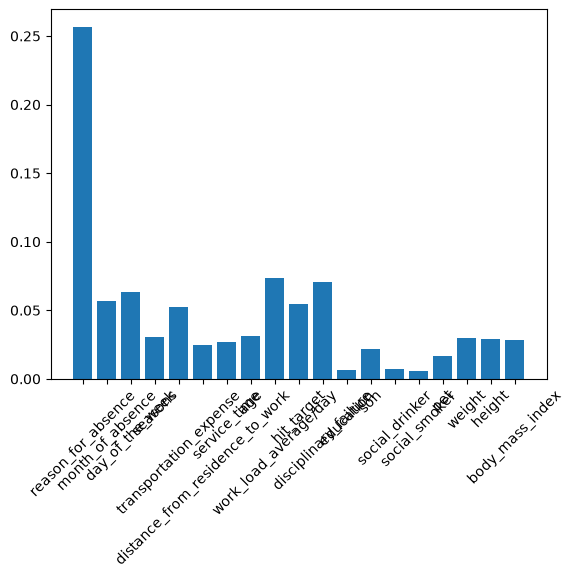

Index(['Unnamed: 0', 'reason_for_absence', 'month_of_absence',
       'day_of_the_week', 'seasons', 'transportation_expense',
       'distance_from_residence_to_work', 'service_time', 'age',
       'work_load_average/day', 'hit_target', 'disciplinary_failure',
       'education', 'son', 'social_drinker', 'social_smoker', 'pet', 'weight',
       'height', 'body_mass_index'],
      dtype='str')


In [12]:
plt.bar(x.columns[1:], model.feature_importances_[1:])
plt.xticks(rotation=45)
plt.show()
print(x.columns)